<a href="https://colab.research.google.com/github/Subhranshu-123/BIKE2/blob/main/Copy_of_indigo_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
df = pd.read_csv("/content/INDIGO.NS_stock_data.csv")

df.head()

,Unnamed: 0,open,high,low,close,adjclose,volume,ticker
0,11/10/2015,855.799988,899.500000,849.000000,877.250000,831.624573,27351793,INDIGO.NS
1,11/13/2015,918.000000,1032.000000,917.000000,1004.099976,951.877136,8446622,INDIGO.NS
2,11/16/2015,1011.000000,1040.000000,966.250000,988.950012,937.515137,3358159,INDIGO.NS
3,11/17/2015,990.000000,1049.900024,976.200012,1036.900024,982.971252,3694092,INDIGO.NS
4,11/18/2015,1017.250000,1068.800049,1015.299988,1045.650024,991.266235,3621593,INDIGO.NS


In [ ]:
df['date'] = pd.to_datetime(df['Unnamed: 0'])

df.set_index('date', inplace=True)

In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'adjclose', 'volume',
       'ticker'],
      dtype='object')


In [ ]:
df.dropna(subset=['adjclose'], inplace=True)

In [ ]:
print(df)

            Unnamed: 0         open         high          low        close  \
date                                                                         
2015-11-10  11/10/2015   855.799988   899.500000   849.000000   877.250000   
2015-11-13  11/13/2015   918.000000  1032.000000   917.000000  1004.099976   
2015-11-16  11/16/2015  1011.000000  1040.000000   966.250000   988.950012   
2015-11-17  11/17/2015   990.000000  1049.900024   976.200012  1036.900024   
2015-11-18  11/18/2015  1017.250000  1068.800049  1015.299988  1045.650024   
...                ...          ...          ...          ...          ...   
2024-04-23   4/23/2024  3722.050049  3733.449951  3673.000000  3702.550049   
2024-04-24   4/24/2024  3719.899902  3766.350098  3705.000000  3742.199951   
2024-04-25   4/25/2024  3739.949951  3829.000000  3727.149902  3812.550049   
2024-04-26   4/26/2024  3858.000000  3972.000000  3835.000000  3935.350098   
2024-04-29   4/29/2024  4001.000000  4009.949951  3875.000000  3

In [ ]:
df = df.dropna(how='any')

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
open,0
high,0
low,0
close,0
adjclose,0
volume,0
ticker,0


In [ ]:
df = df[['adjclose']]

In [ ]:
print(df)

               adjclose
date                   
2015-11-10   831.624573
2015-11-13   951.877136
2015-11-16   937.515137
2015-11-17   982.971252
2015-11-18   991.266235
...                 ...
2024-04-23  3702.550049
2024-04-24  3742.199951
2024-04-25  3812.550049
2024-04-26  3935.350098
2024-04-29  3927.699951

[2088 rows x 1 columns]


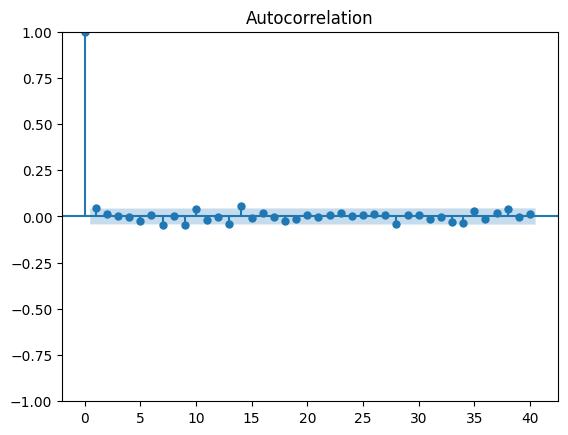

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

df['diff'] = df['adjclose'].diff() # Ensure 'diff' column exists
plot_acf(df['diff'].dropna(), lags=40)
plt.show()

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import acf

series = df['diff'].dropna()

acf_vals = acf(series, nlags=20)

threshold = 1.96 / np.sqrt(len(series))

ma_order = 0

for i in range(1, len(acf_vals)):
    if abs(acf_vals[i]) > threshold:
        ma_order = i

print("Estimated MA order (q):", ma_order)

Estimated MA order (q): 14


In [ ]:
print(acf_vals)

[ 1.          0.04380841  0.01275259  0.00199837 -0.00234183 -0.02361523
  0.00840467 -0.04353001  0.00501601 -0.04630393  0.04257749 -0.02044161
 -0.00100498 -0.04058074  0.05530558 -0.00719479  0.01642521 -0.00294244
 -0.02490985 -0.01524718  0.00559314]


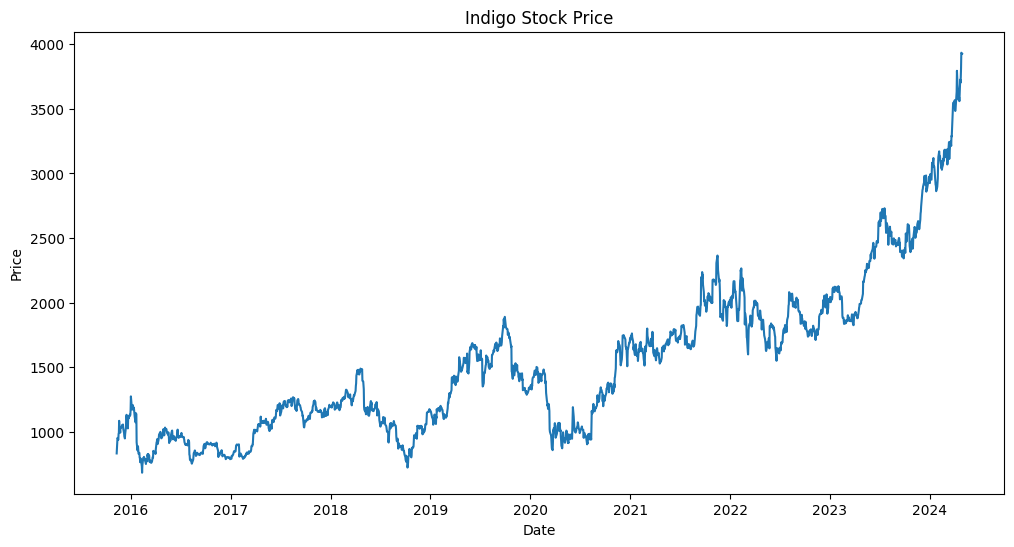

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['adjclose'])
plt.title("Indigo Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Decision
p-value	Result
< 0.05	Stationary
> 0.05	Non-stationary

Stock prices are usually non-stationary.

In [ ]:
result = adfuller(df['adjclose'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 1.510115607225477
p-value: 0.9975612141107838


Decision
p-value	Result
< 0.05	Non-stationary
> 0.05	Stationary

In [ ]:
stat, p_value, lags, critical = kpss(df['adjclose'])

print("KPSS Statistic:", stat)
print("p-value:", p_value)

KPSS Statistic: 5.604996451369118
p-value: 0.01


/tmp/ipykernel_632/2273388550.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, critical = kpss(df['adjclose'])


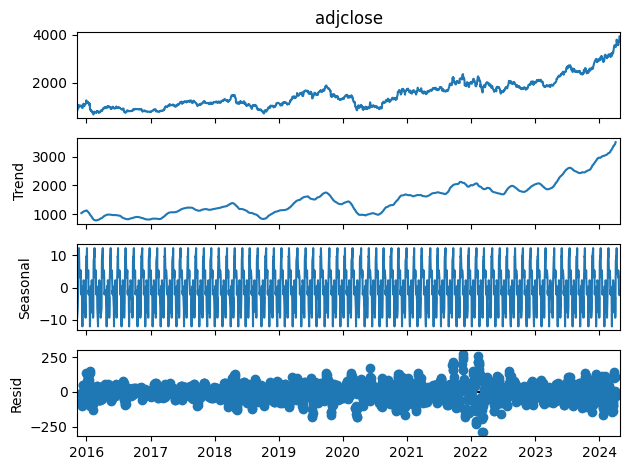

In [ ]:
decompose = seasonal_decompose(df['adjclose'], model='additive', period=30)

decompose.plot()
plt.show()

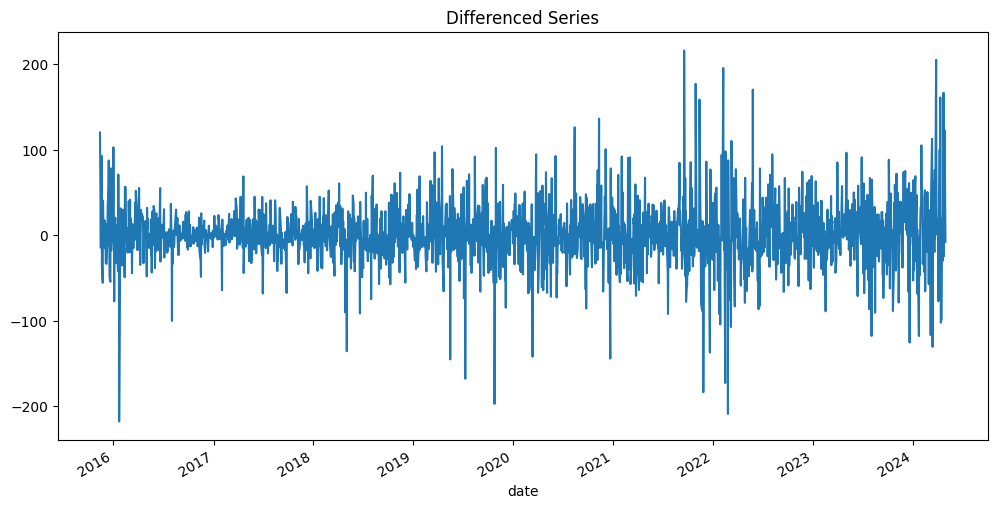

In [ ]:
df['diff'] = df['adjclose'].diff()

df['diff'].dropna().plot(figsize=(12,6))
plt.title("Differenced Series")
plt.show()

In [ ]:
adf_result = adfuller(df['diff'].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -12.153392612874017
p-value: 1.5517297185817438e-22


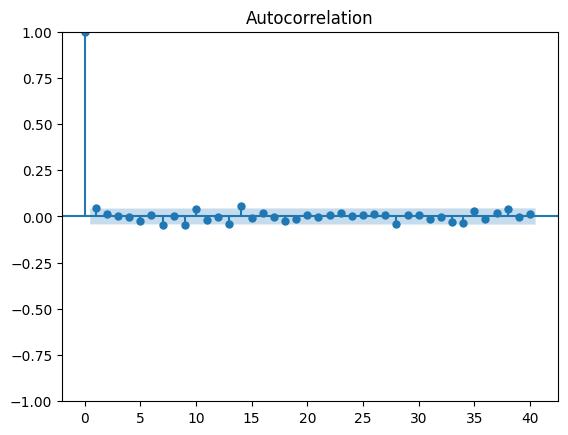

In [ ]:
plot_acf(df['diff'].dropna(), lags=40)
plt.show()

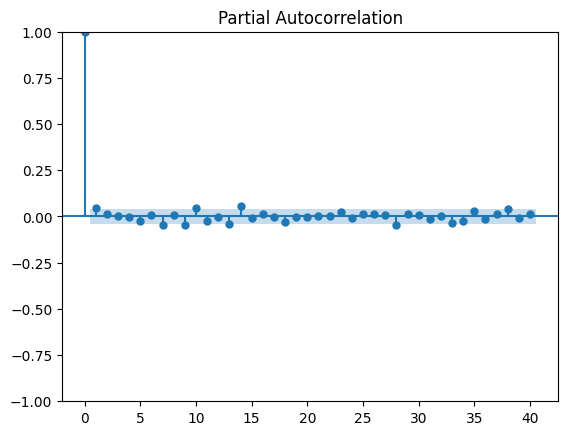

In [ ]:
plot_pacf(df['diff'].dropna(), lags=40)
plt.show()

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import pacf

series = df['diff'].dropna()

pacf_vals = pacf(series, nlags=20)

threshold = 1.96 / np.sqrt(len(series))

ar_order = 0

for i in range(1, len(pacf_vals)):
    if abs(pacf_vals[i]) > threshold:
        ar_order = i

print("Estimated AR order (p):", ar_order)

Estimated AR order (p): 14


In [ ]:
print(pacf_vals)

[ 1.00000000e+00  4.38294112e-02  1.08646814e-02  9.73641020e-04
 -2.61923091e-03 -2.35392081e-02  1.05558977e-02 -4.40547962e-02
  8.75924379e-03 -4.64703589e-02  4.67169315e-02 -2.36701542e-02
 -1.64025291e-03 -4.00040488e-02  5.63692763e-02 -8.69658667e-03
  1.10773230e-02 -3.41127656e-04 -3.13106197e-02 -5.26265563e-03
 -1.76612165e-03]


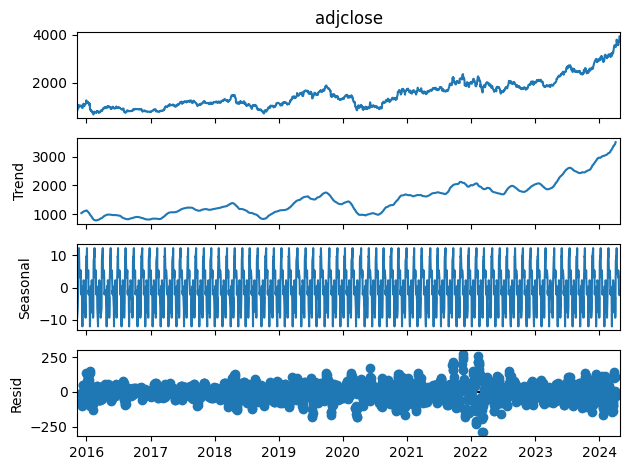

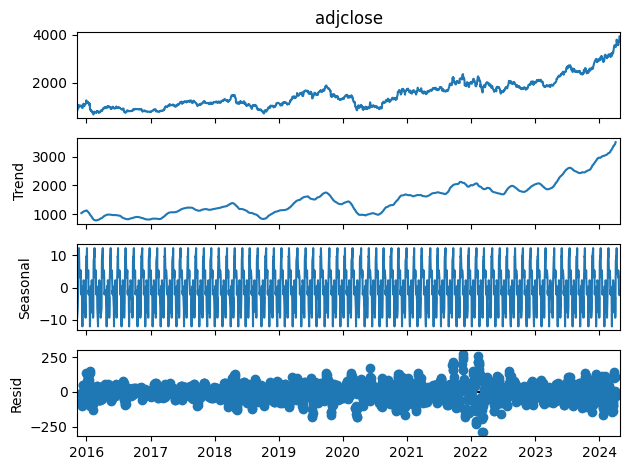

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['adjclose'], model='additive', period=30)
result.plot()

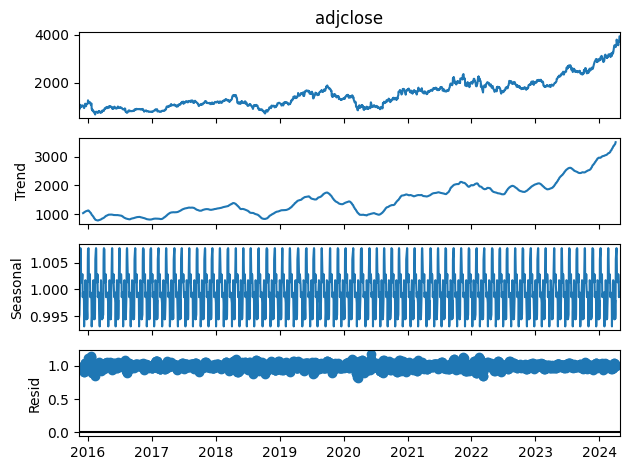

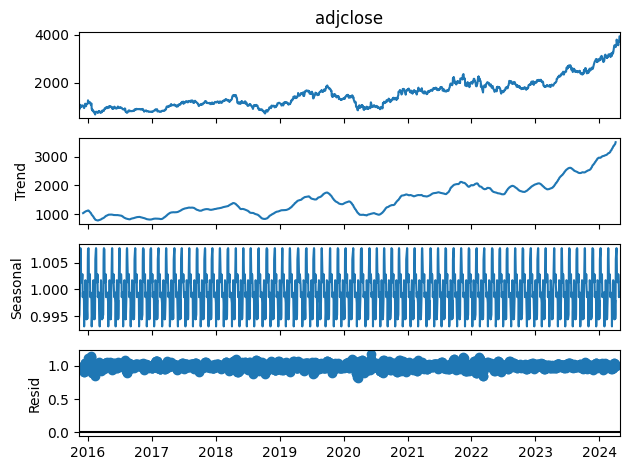

In [ ]:
result = seasonal_decompose(df['adjclose'], model='multiplicative', period=30)
result.plot()

In [ ]:
import numpy as np

df['log_adjclose'] = np.log(df['adjclose'])

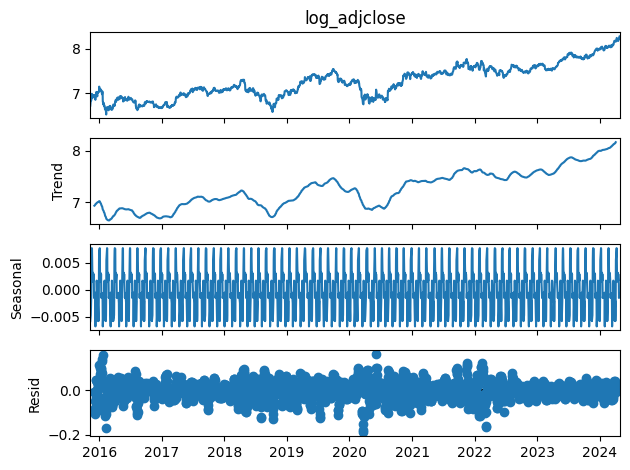

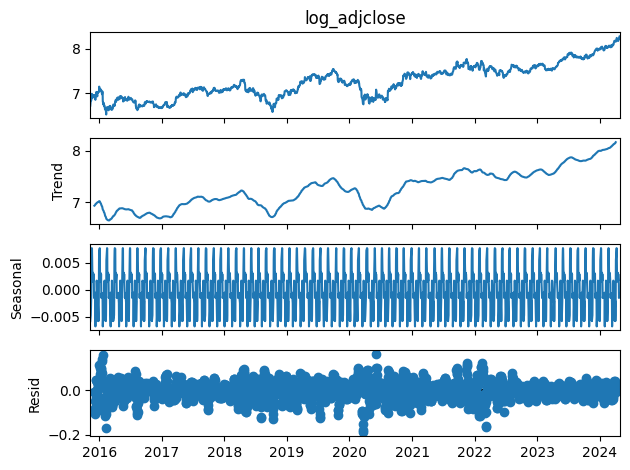

In [ ]:
result = seasonal_decompose(df['log_adjclose'], model='additive', period=30)
result.plot()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['adjclose'], order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:               adjclose   No. Observations:                 2088
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -10438.712
Date:                Tue, 10 Mar 2026   AIC                          20883.423
Time:                        11:06:58   BIC                          20900.353
Sample:                             0   HQIC                         20889.626
                               - 2088                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2822      0.370      0.763      0.446      -0.443       1.007
ma.L1         -0.2368      0.375     -0.631      0.528      -0.972       0.498
sigma2      1294.3103     20.941     61.807      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


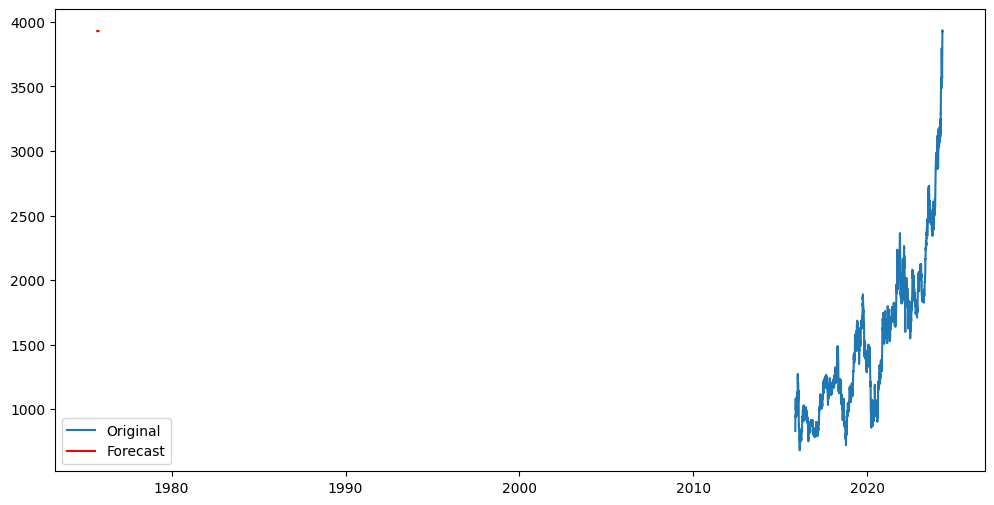

In [ ]:
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(12,6))
plt.plot(df['adjclose'], label="Original")
plt.plot(forecast, label="Forecast", color='red')
plt.legend()
plt.show()